# Collaborative Filtering Recommendation

Build user-based and item-based collaborative filtering models from scratch.

**Algorithms covered:**
- User-Based CF (find similar users, use their ratings)
- Item-Based CF (find similar items, use user's history)

In [57]:
import sys
sys.path.append('../src')
sys.path.append('../evaluation')

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import MovieLensDataLoader
from metrics import rmse, mae, precision_at_k, recall_at_k, ndcg_at_k

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Setup complete ')

Setup complete 


## 1. Load Data

In [58]:
# Load via DataLoader so we also get movie titles
loader = MovieLensDataLoader()
ratings, movies, users = loader.load_data()
user_item_matrix = loader.get_user_item_matrix()
movie_titles = loader.get_movie_titles()

print(f'Ratings shape: {ratings.shape}')
print(f'User-Item Matrix: {user_item_matrix.shape}')
print(f'Sample titles: {list(movie_titles.values())[:3]}')

Ratings shape: (100000, 4)
User-Item Matrix: (943, 1682)
Sample titles: ['Toy Story (1995)', 'GoldenEye (1995)', 'Four Rooms (1995)']


## 2. Train / Test Split

In [59]:
# Split ratings, then build train matrix
train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=42)

train_matrix = train_ratings.pivot_table(index='user_id', columns='item_id', values='rating')
test_matrix = test_ratings.pivot_table(index='user_id', columns='item_id', values='rating')

print(f'Train ratings: {len(train_ratings):,}')
print(f'Test ratings: {len(test_ratings):,}')
print(f'Train matrix: {train_matrix.shape}')

Train ratings: 80,000
Test ratings: 20,000
Train matrix: (943, 1653)


## 3. User-Based Collaborative Filtering

In [60]:
class UserBasedCF:
    """User-based collaborative filtering"""

    def __init__(self, matrix, n_neighbors=10):
        self.matrix = matrix.fillna(0)
        self.n_neighbors = n_neighbors
        self.similarities = None

    def fit(self):
        """Compute user-user cosine similarities"""
        self.similarities = cosine_similarity(self.matrix)
        return self

    def predict(self, user_id, item_id):
        """Predict rating for user-item pair"""
        if user_id not in self.matrix.index or item_id not in self.matrix.columns:
            return float(self.matrix.values[self.matrix.values > 0].mean())

        user_idx = list(self.matrix.index).index(user_id)
        sims = self.similarities[user_idx]

        similar_indices = np.argsort(sims)[::-1][1:self.n_neighbors + 1]
        similar_sims    = sims[similar_indices]
        similar_ratings = self.matrix.iloc[similar_indices][item_id].values

        valid = similar_ratings > 0
        if not valid.any():
            return float(self.matrix[item_id].mean())

        return float((similar_ratings[valid] * similar_sims[valid]).sum() / similar_sims[valid].sum())

    def recommend_for_user(self, user_id, n_items=10):
        """Top-N items not yet rated by the user"""
        if user_id not in self.matrix.index:
            return []
        user_row = self.matrix.loc[user_id]
        unrated  = user_row[user_row == 0].index.tolist()
        scores   = [(item, self.predict(user_id, item)) for item in unrated]
        scores.sort(key=lambda x: x[1], reverse=True)
        return [item for item, _ in scores[:n_items]]


# Train
user_cf = UserBasedCF(train_matrix, n_neighbors=10)
user_cf.fit()
print('User-based CF model trained')


User-based CF model trained


## 4. Evaluate User-Based CF

In [61]:
predictions, actual = [], []

for _, row in test_ratings.head(200).iterrows():
    uid, iid, r = int(row['user_id']), int(row['item_id']), row['rating']
    if uid in train_matrix.index and iid in train_matrix.columns:
        predictions.append(user_cf.predict(uid, iid))
        actual.append(r)

if predictions:
    print('User-Based CF Results:')
    print(f'  RMSE: {rmse(actual, predictions):.4f}')
    print(f'  MAE:  {mae(actual, predictions):.4f}')
    print(f'  Samples evaluated: {len(predictions)}')


User-Based CF Results:
  RMSE: 1.3841
  MAE:  1.0216
  Samples evaluated: 200


## 5. Get Recommendations (with Movie Titles)

In [62]:
sample_user = 1
recommendations = user_cf.recommend_for_user(sample_user, n_items=10)

print(f'Top 10 recommendations for User {sample_user} (User-Based CF):')
print(f'{"Rank":>5}  {"Item ID":>8}  Title')
print('-' * 55)
for rank, item_id in enumerate(recommendations, start=1):
    print(f'{rank:>5}  {item_id:>8}  {movie_titles.get(item_id, "Unknown")}')


Top 10 recommendations for User 1 (User-Based CF):
 Rank   Item ID  Title
-------------------------------------------------------
    1       262  In the Company of Men (1997)
    2       313  Titanic (1997)
    3       331  Edge, The (1997)
    4       492  East of Eden (1955)
    5       512  Wings of Desire (1987)
    6       513  Third Man, The (1949)
    7       602  American in Paris, An (1951)
    8       603  Rear Window (1954)
    9       653  Touch of Evil (1958)
   10       834  Halloween: The Curse of Michael Myers (1995)


## 6. Item-Based Collaborative Filtering

In [63]:
class ItemBasedCF:
    """Item-based collaborative filtering"""

    def __init__(self, matrix, n_neighbors=10):
        self.matrix = matrix.fillna(0)
        self.n_neighbors = n_neighbors
        self.similarities = None

    def fit(self):
        """Compute item-item cosine similarities"""
        self.similarities = cosine_similarity(self.matrix.T)
        return self

    def predict(self, user_id, item_id):
        """Predict rating for user-item pair"""
        if user_id not in self.matrix.index or item_id not in self.matrix.columns:
            return float(self.matrix.values[self.matrix.values > 0].mean())

        item_idx   = list(self.matrix.columns).index(item_id)
        sims       = self.similarities[item_idx]
        user_row   = self.matrix.loc[user_id].values
        rated_mask = user_row > 0

        if not rated_mask.any():
            return float(self.matrix.mean().mean())

        weighted = (user_row[rated_mask] * sims[rated_mask]).sum()
        total    = sims[rated_mask].sum()
        return float(weighted / total) if total > 0 else float(self.matrix.mean().mean())

    def recommend_for_user(self, user_id, n_items=10):
        """Top-N items not yet rated by the user"""
        if user_id not in self.matrix.index:
            return []
        user_row = self.matrix.loc[user_id]
        unrated  = user_row[user_row == 0].index.tolist()
        scores   = [(item, self.predict(user_id, item)) for item in unrated]
        scores.sort(key=lambda x: x[1], reverse=True)
        return [item for item, _ in scores[:n_items]]


# Train
item_cf = ItemBasedCF(train_matrix, n_neighbors=10)
item_cf.fit()
print('Item-based CF model trained')


Item-based CF model trained


## 7. Compare User-Based vs Item-Based CF

Model                    RMSE      MAE
------------------------------------------
User-Based CF          1.3841   1.0216
Item-Based CF          0.9555   0.7861


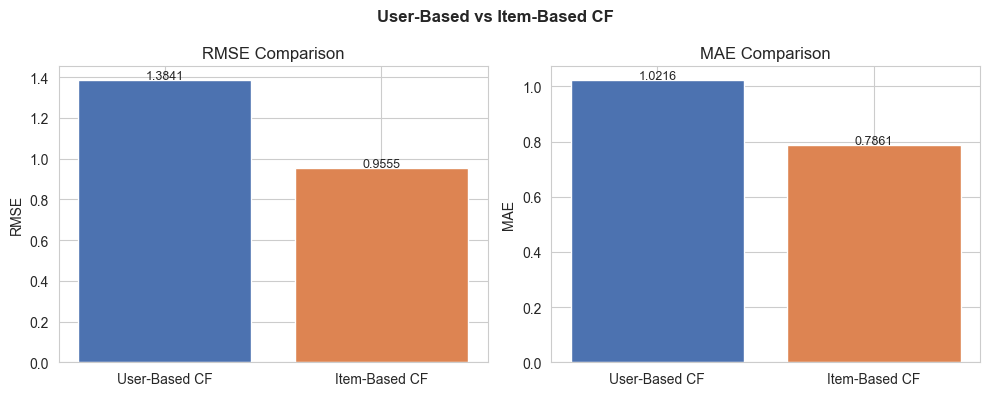

In [64]:
u_preds, i_preds, actuals = [], [], []

for _, row in test_ratings.head(200).iterrows():
    uid, iid, r = int(row['user_id']), int(row['item_id']), row['rating']
    if uid in train_matrix.index and iid in train_matrix.columns:
        u_preds.append(user_cf.predict(uid, iid))
        i_preds.append(item_cf.predict(uid, iid))
        actuals.append(r)

if u_preds:
    results = {
        'User-Based CF': {'RMSE': rmse(actuals, u_preds), 'MAE': mae(actuals, u_preds)},
        'Item-Based CF': {'RMSE': rmse(actuals, i_preds), 'MAE': mae(actuals, i_preds)},
    }

    print(f'{"Model":20s} {"RMSE":>8} {"MAE":>8}')
    print('-' * 42)
    for name, m in results.items():
        print(f'{name:20s} {m["RMSE"]:>8.4f} {m["MAE"]:>8.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, metric in zip(axes, ['RMSE', 'MAE']):
        vals = [results[m][metric] for m in results]
        bars = ax.bar(list(results.keys()), vals, color=['#4C72B0', '#DD8452'])
        ax.set_title(f'{metric} Comparison')
        ax.set_ylabel(metric)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.4f}',
                    ha='center', fontsize=9)
    plt.suptitle('User-Based vs Item-Based CF', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. Top-N Ranking Metrics (Precision / Recall / NDCG @10)

In [65]:
K = 10
THRESHOLD = 4
EVAL_USERS = 30

relevant_items = (
    test_ratings[test_ratings['rating'] >= THRESHOLD]
    .groupby('user_id')['item_id'].apply(set).to_dict()
)
eval_users = [u for u in list(relevant_items.keys()) if u in train_matrix.index][:EVAL_USERS]

u_p, u_r, u_n = [], [], []
i_p, i_r, i_n = [], [], []

for uid in eval_users:
    ground = relevant_items.get(uid, set())
    u_recs = user_cf.recommend_for_user(uid, K)
    i_recs = item_cf.recommend_for_user(uid, K)
    u_p.append(precision_at_k(u_recs, ground, K))
    u_r.append(recall_at_k(u_recs, ground, K))
    u_n.append(ndcg_at_k(u_recs, ground, K))
    i_p.append(precision_at_k(i_recs, ground, K))
    i_r.append(recall_at_k(i_recs, ground, K))
    i_n.append(ndcg_at_k(i_recs, ground, K))

print(f'Top-{K} Ranking Metrics (avg over {len(eval_users)} users):')
print(f'{"Model":20s} {"P@K":>8} {"R@K":>8} {"NDCG@K":>9}')
print('-' * 52)
print(f'{"User-Based CF":20s} {np.mean(u_p):>8.4f} {np.mean(u_r):>8.4f} {np.mean(u_n):>9.4f}')
print(f'{"Item-Based CF":20s} {np.mean(i_p):>8.4f} {np.mean(i_r):>8.4f} {np.mean(i_n):>9.4f}')

Top-10 Ranking Metrics (avg over 30 users):
Model                     P@K      R@K    NDCG@K
----------------------------------------------------
User-Based CF          0.0400   0.0609    0.0661
Item-Based CF          0.0000   0.0000    0.0000


## 9. User Similarity Heatmap

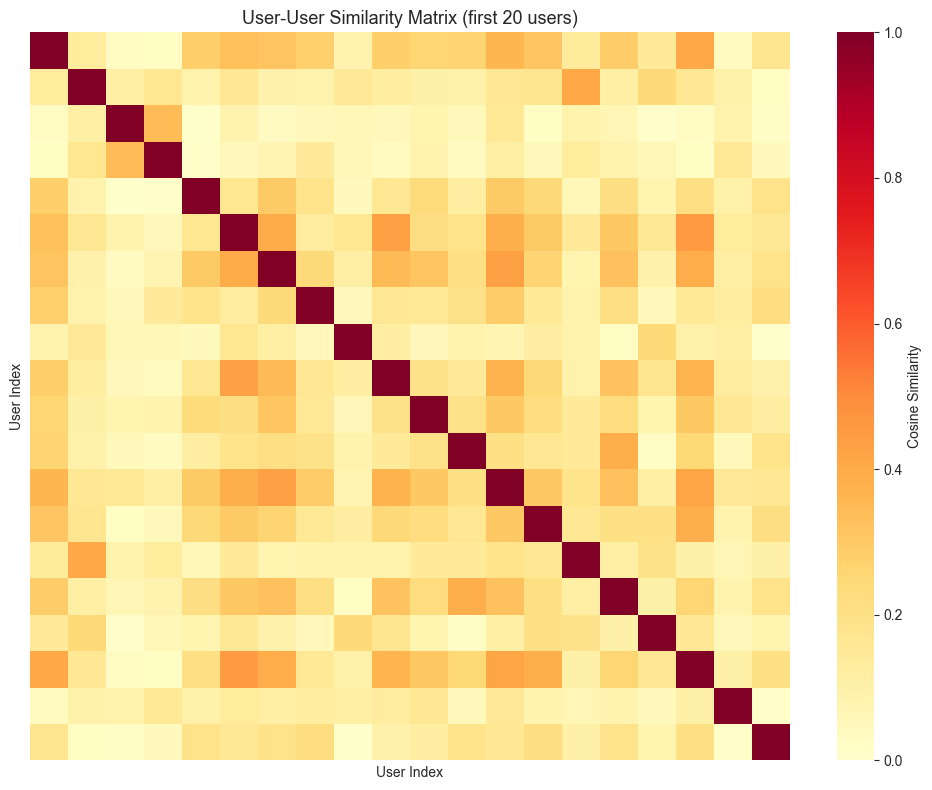

In [66]:
sim_sample = user_cf.similarities[:20, :20]

plt.figure(figsize=(10, 8))
sns.heatmap(sim_sample, cmap='YlOrRd', xticklabels=False, yticklabels=False,
cbar_kws={'label': 'Cosine Similarity'})
plt.title('User-User Similarity Matrix (first 20 users)', fontsize=13)
plt.xlabel('User Index')
plt.ylabel('User Index')
plt.tight_layout()
plt.show()

## 10. Item-Based Recommendations with User History

In [67]:
sample_user = 1
i_recs = item_cf.recommend_for_user(sample_user, n_items=10)

print(f'Top 10 recommendations for User {sample_user} (Item-Based CF):')
print(f'{"Rank":>5} {"Item ID":>8} Title')
print('-' * 55)
for rank, item_id in enumerate(i_recs, start=1):
    print(f'{rank:>5} {item_id:>8} {movie_titles.get(item_id, "Unknown")}')

# Show which movies the user already liked
liked = ratings[(ratings['user_id'] == sample_user) & (ratings['rating'] >= 4)]
print(f'\nUser {sample_user} already highly rated ({len(liked)} movies, showing first 5):')
for _, r in liked.head(5).iterrows():
    print(f'  * {movie_titles.get(int(r["item_id"]), "Unknown")} (rating={r["rating"]})')

Top 10 recommendations for User 1 (Item-Based CF):
 Rank  Item ID Title
-------------------------------------------------------
    1     1671 Further Gesture, A (1996)
    2     1104 C'est arrivé près de chez vous (1992)
    3     1642 Some Mother's Son (1996)
    4     1600 Guantanamera (1994)
    5     1251 A Chef in Love (1996)
    6      850 Perfect Candidate, A (1996)
    7     1241 Van, The (1996)
    8     1332 My Life and Times With Antonin Artaud (En compagnie d'Antonin Artaud) (1993)
    9     1606 Deceiver (1997)
   10     1466 Margaret's Museum (1995)

User 1 already highly rated (163 movies, showing first 5):
  * Three Colors: White (1994) (rating=4)
  * Desperado (1995) (rating=4)
  * Glengarry Glen Ross (1992) (rating=4)
  * Angels and Insects (1995) (rating=4)
  * Groundhog Day (1993) (rating=5)
